![Screenshot 2026-03-25 115357.png](<attachment:Screenshot 2026-03-25 115357.png>)
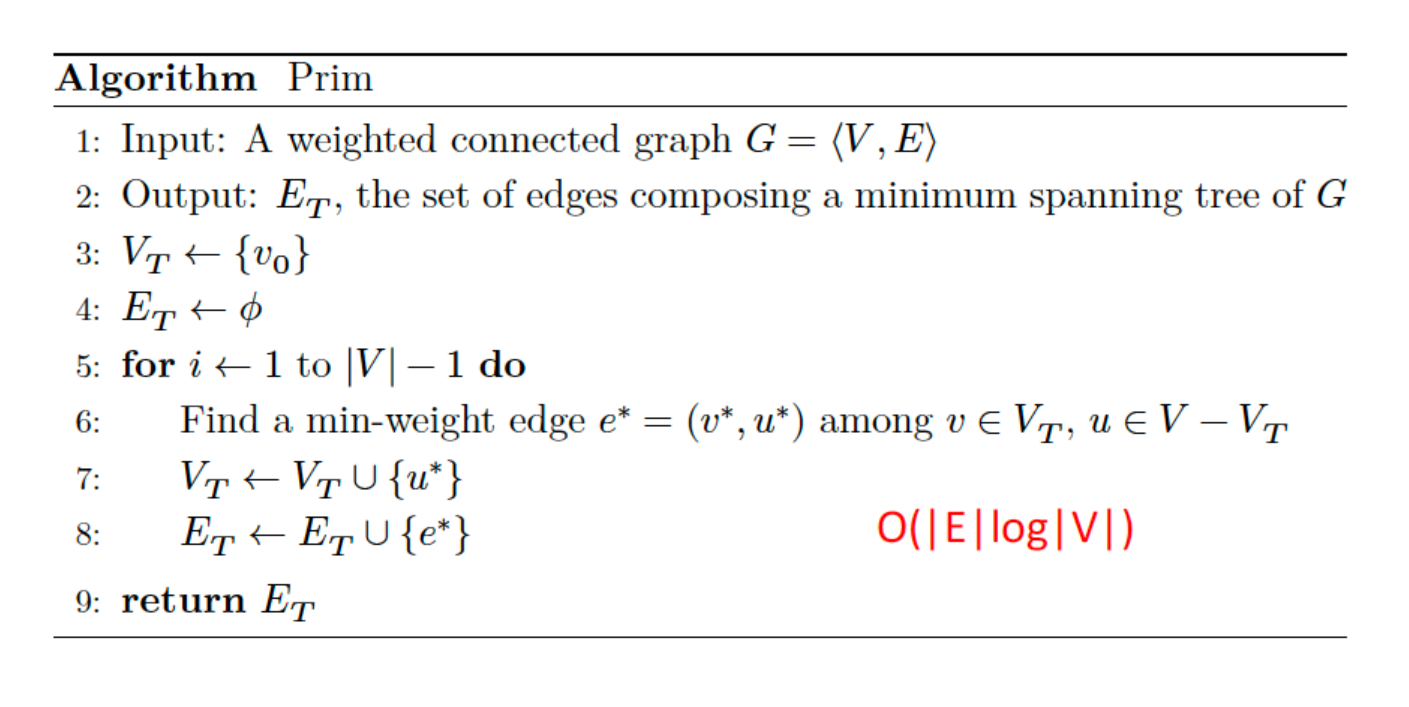

In [34]:
import heapq
def prim(graph, start):
    # V_T ← {v0}
    visited = set([start])
    # E_T ← ∅
    mst_edges = []
    total_weight = 0
    # heap เก็บ (weight, from, to)
    edges = [] # ใส่ edge เริ่มต้น
    for to, weight in graph[start]:
        heapq.heappush(edges, (weight, start, to))
    # for i ← 1 to |V| − 1 do
    while len(visited) < len(graph):
        # หา edge ที่เล็กสุด
        weight, frm, to = heapq.heappop(edges)
        # ถ้า node ยังไม่ถูกเลือก
        if to not in visited:
            # V_T ← V_T ∪ {u*}
            visited.add(to)
            # E_T ← E_T ∪ {e*}
            mst_edges.append((frm, to, weight))
            total_weight += weight
            # เพิ่ม edge ใหม่เข้า heap
            for next_to, next_weight in graph[to]:
                if next_to not in visited:
                    heapq.heappush(edges, (next_weight, to, next_to))

    # return E_T
    return mst_edges, total_weight

![Screenshot 2026-03-25 115717.png](<attachment:Screenshot 2026-03-25 115717.png>)
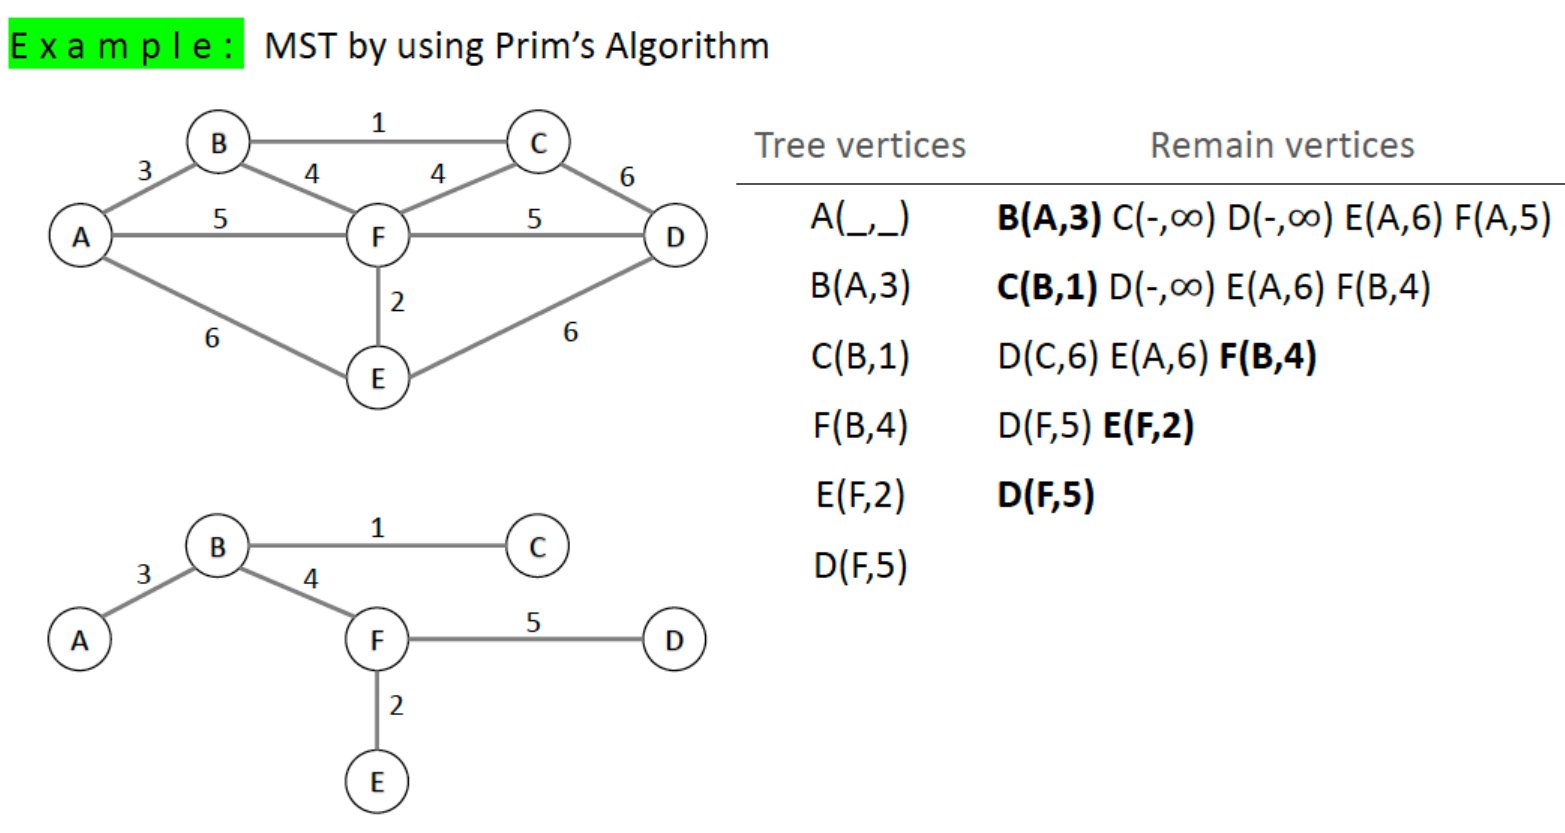

In [35]:
graph = {
    'A': [('B', 3), ('F', 5), ('E', 6)],
    'B': [('A', 3), ('C', 1), ('F', 4)],
    'C': [('B', 1), ('F', 4), ('D', 6)],
    'D': [('C', 6), ('F', 5), ('E', 6)],
    'E': [('A', 6), ('F', 2), ('D', 6)],
    'F': [('A', 5), ('B', 4), ('C', 4), ('D', 5), ('E', 2)]
}

mst, total = prim(graph, 'A')
print(mst)
print("MST edges:")
for u, v, w in mst:
    print(f"{u} - {v} : {w}")

print("Total weight =", total)

[('A', 'B', 3), ('B', 'C', 1), ('B', 'F', 4), ('F', 'E', 2), ('F', 'D', 5)]
MST edges:
A - B : 3
B - C : 1
B - F : 4
F - E : 2
F - D : 5
Total weight = 15


![Screenshot 2026-03-25 120314.png](<attachment:Screenshot 2026-03-25 120314.png>)
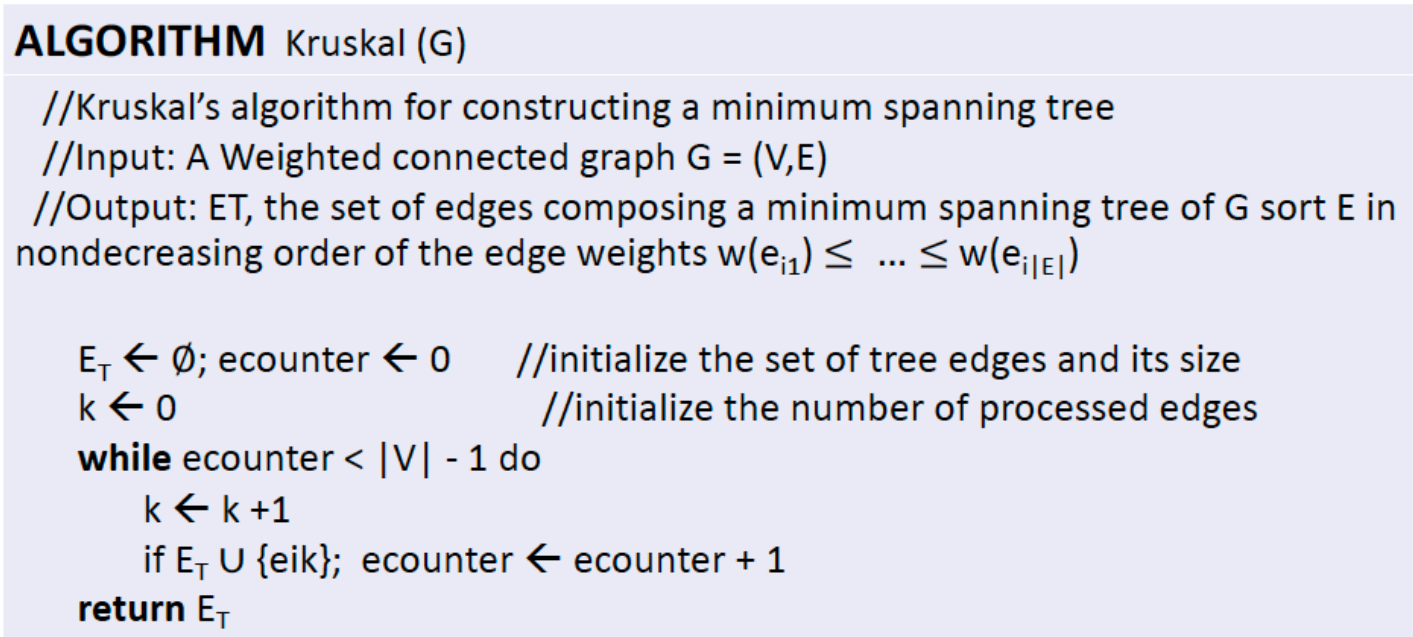

In [36]:
def find(parent, x): #หา root ของ x
    if parent[x] != x:
        parent[x] = find(parent, parent[x])
    return parent[x]

def union(parent, rank, x, y): #รวมชุดของ x และ y
    rootX = find(parent, x)
    rootY = find(parent, y)

    if rootX != rootY:
        if rank[rootX] > rank[rootY]:
            parent[rootY] = rootX
        elif rank[rootX] < rank[rootY]:
            parent[rootX] = rootY
        else:
            parent[rootY] = rootX
            rank[rootX] += 1
        return True
    return False


def kruskal(graph): #ไม่ต้อง import heapq เพราะไม่ใช้ heap
    edges = []

    # แปลงเป็น edge list
    for u in graph:
        for v, w in graph[u]:
            if (v, u, w) not in edges:
                edges.append((u, v, w))

    # เรียงน้ำหนัก
    edges.sort(key=lambda x: x[2])

    parent = {v: v for v in graph}
    rank = {v: 0 for v in graph}

    mst = []
    total_weight = 0

    for u, v, w in edges:
        if union(parent, rank, u, v):
            mst.append((u, v, w))
            total_weight += w

        # หยุดเมื่อครบ |V|-1
        if len(mst) == len(graph) - 1:
            break

    return mst, total_weight

![Screenshot 2026-03-25 121016.png](<attachment:Screenshot 2026-03-25 121016.png>)
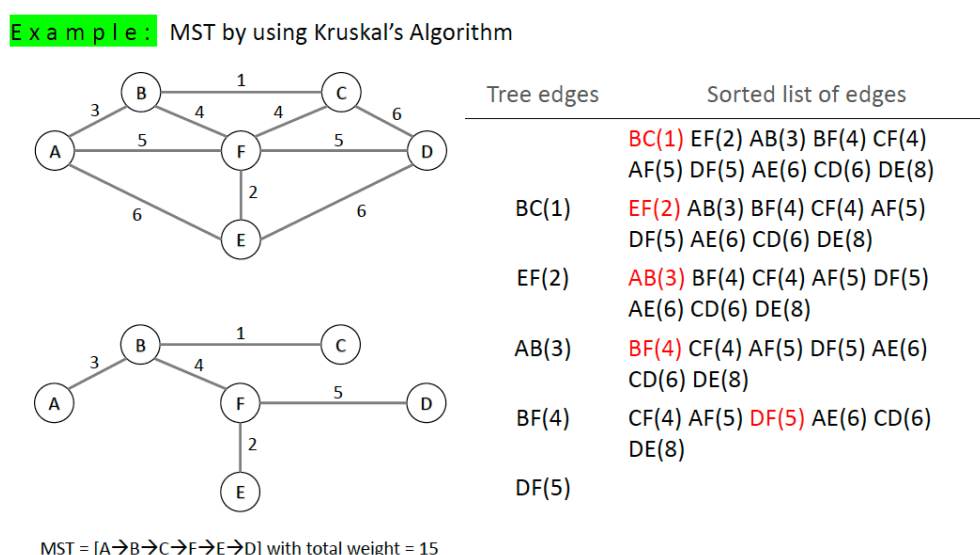

In [37]:
graph = {
    'A': [('B', 3), ('F', 5), ('E', 6)],
    'B': [('A', 3), ('C', 1), ('F', 4)],
    'C': [('B', 1), ('F', 4), ('D', 6)],
    'D': [('C', 6), ('F', 5), ('E', 6)],
    'E': [('A', 6), ('F', 2), ('D', 6)],
    'F': [('A', 5), ('B', 4), ('C', 4), ('D', 5), ('E', 2)]
}

mst, total = kruskal(graph)

print(mst)
print("MST edges:")
for u, v, w in mst:
    print(f"{u} - {v} : {w}")

print("Total weight =", total)

[('B', 'C', 1), ('E', 'F', 2), ('A', 'B', 3), ('B', 'F', 4), ('D', 'F', 5)]
MST edges:
B - C : 1
E - F : 2
A - B : 3
B - F : 4
D - F : 5
Total weight = 15


![Screenshot 2026-03-25 122616.png](<attachment:Screenshot 2026-03-25 122616.png>)
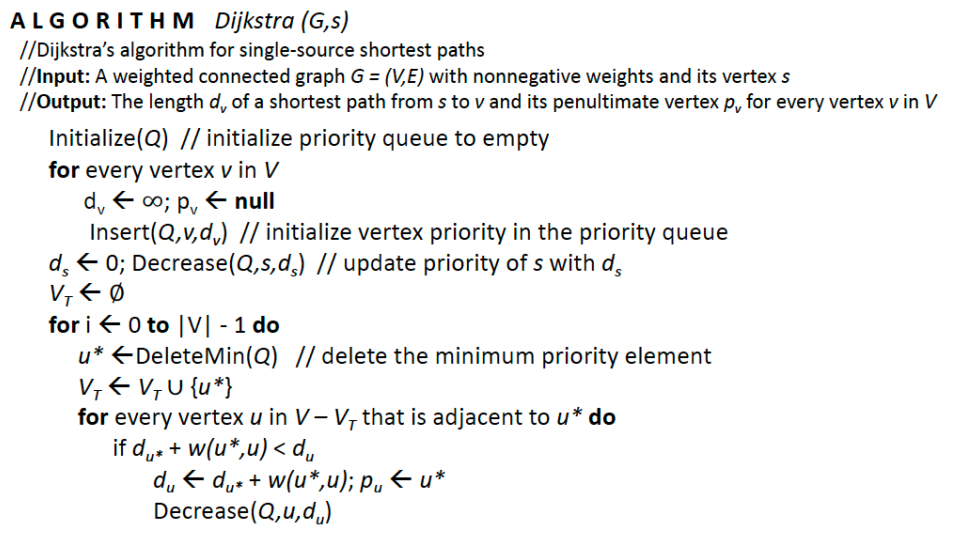

In [38]:
import heapq
def get_path(parent, target): # สร้าง path จาก target กลับไปยัง start โดยใช้ parentตามในโจทย์
    path = []
    while target:
        path.append(target)
        target = parent[target]
    return path[::-1]

def dijkstra(graph, start):
    # for every vertex v in V: d[v] ← ∞ , p[v] ← null
    dist = {v: float('inf') for v in graph}
    parent = {v: None for v in graph}

    pq = [] # Initialize(Q)
    dist[start] = 0 # d[s] ← 0

    heapq.heappush(pq, (0, start)) # Insert(Q, s, d[s])
    visited = set() # V_T ← ∅

    # for i ← 0 to |V|-1 do
    while pq:
        # u* ← DeleteMin(Q)
        current_dist, u = heapq.heappop(pq)
        if u in visited:
            continue
        # V_T ← V_T ∪ {u*}
        visited.add(u)

        # for every vertex u adjacent to u*
        for v, weight in graph[u]:
            # if d[u*] + w(u*,v) < d[v]
            if dist[u] + weight < dist[v]:
                # update
                dist[v] = dist[u] + weight
                parent[v] = u
                # Decrease(Q, v, d[v])
                heapq.heappush(pq, (dist[v], v))

    return dist, parent

![Screenshot 2026-03-25 122919.png](<attachment:Screenshot 2026-03-25 122919.png>)
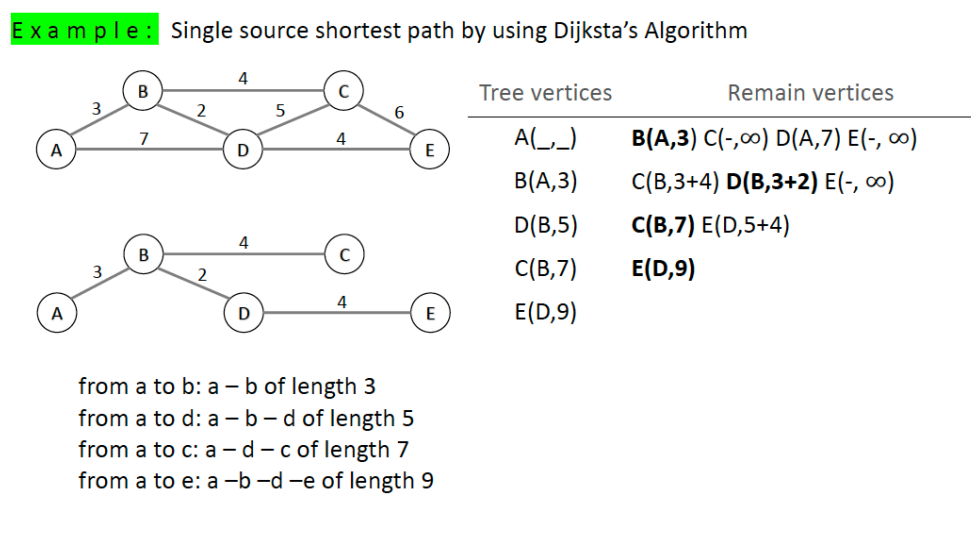

In [39]:
graph = {
    'A': [('B', 3), ('D', 7)],
    'B': [('A', 3), ('C', 4), ('D', 2)],
    'C': [('B', 4), ('D', 2)],
    'D': [('A', 7), ('B', 2), ('C', 2), ('E', 4)],
    'E': [('D', 4)]
}

dist, parent = dijkstra(graph, 'A')
print(dist)
print("Final Answer:")

for v in graph:
    path = get_path(parent, v)
    print(f"from A to {v}: {' - '.join(path)} of length {dist[v]}")

{'A': 0, 'B': 3, 'C': 7, 'D': 5, 'E': 9}
Final Answer:
from A to A: A of length 0
from A to B: A - B of length 3
from A to C: A - B - C of length 7
from A to D: A - B - D of length 5
from A to E: A - B - D - E of length 9
